# 07 — SCAFFOLD under client heterogeneity

Notebook 06 showed that moderate FedProx consistently contracts client updates, but its performance and fairness benefits vary across seeded client populations. This notebook tests whether explicitly correcting client drift with SCAFFOLD produces more consistent improvements.

**Primary question**

> Does sample-size-weighted SCAFFOLD improve performance, worst-client accuracy, or update agreement more consistently than FedAvg and moderate FedProx (`mu = 0.1`) under the same seeded partitions?

This implementation uses full participation and sample-size-weighted model and control-variate aggregation so that all three methods use the same global objective. The seed—not a client or round—is the experimental unit.

## 1. Imports and repository integration

Run this notebook from the repository or from its `notebooks/` directory. Keep repository-specific imports in this section.

In [1]:
from __future__ import annotations

import copy
import json
import random
import sys
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any, Dict, Mapping, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")

Python: 3.12.13
PyTorch: 2.10.0+cu128
Device: cuda:0


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root. Open this notebook inside the cloned repository."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation import evaluate_clients
try:
    from src.models import SimpleMLP
except ImportError:
    from src.model import SimpleMLP
from src.scaffold import (
    assert_control_state_matches_model,
    initialize_control_state,
    run_scaffold_experiment,
)

print(f"Project root: {PROJECT_ROOT}")

Project root: /kaggle/working/federated-learning-under-heterogeneity


## 2. Frozen configuration

The seeds, partitions, architecture, local epochs, learning rate, rounds, and batch size match Notebook 06. Do not tune SCAFFOLD separately for each seed.

In [3]:
@dataclass(frozen=True)
class ScaffoldConfig:
    seeds: Tuple[int, ...] = (42, 43, 44)
    num_clients: int = 5
    alpha: float = 0.1
    local_epochs: int = 5
    num_rounds: int = 20
    batch_size: int = 64
    learning_rate: float = 0.01
    num_workers: int = 0
    baseline_results_dir: Path = PROJECT_ROOT / "results" / "multiseed_fedprox"
    results_dir: Path = PROJECT_ROOT / "results" / "scaffold_under_heterogeneity"


CONFIG = ScaffoldConfig()
CONFIG.results_dir.mkdir(parents=True, exist_ok=True)

def json_ready(value: Any) -> Any:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, tuple):
        return list(value)
    return value

with (CONFIG.results_dir / "config.json").open("w", encoding="utf-8") as handle:
    json.dump(
        {key: json_ready(value) for key, value in asdict(CONFIG).items()},
        handle,
        indent=2,
    )

CONFIG

ScaffoldConfig(seeds=(42, 43, 44), num_clients=5, alpha=0.1, local_epochs=5, num_rounds=20, batch_size=64, learning_rate=0.01, num_workers=0, baseline_results_dir=PosixPath('/kaggle/working/federated-learning-under-heterogeneity/results/multiseed_fedprox'), results_dir=PosixPath('/kaggle/working/federated-learning-under-heterogeneity/results/scaffold_under_heterogeneity'))

## 3. Dataset and saved Notebook 06 artifacts

Notebook 07 does not generate new partitions or model initializations. It loads the exact saved indices and initial weights from Notebook 06. Client validation and test subsets still come from the MNIST training dataset because those indices were created from that dataset.

In [4]:
from torchvision import datasets, transforms

MNIST_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(
    root=PROJECT_ROOT / "datasets",
    train=True,
    download=True,
    transform=MNIST_TRANSFORM,
)
print(f"MNIST training examples: {len(train_dataset):,}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.10MB/s]

MNIST training examples: 60,000


In [5]:
@dataclass
class SavedSeedArtifacts:
    seed: int
    train_indices: Dict[int, list[int]]
    validation_indices: Dict[int, list[int]]
    test_indices: Dict[int, list[int]]
    initial_state_dict: Dict[str, torch.Tensor]


def load_index_mapping(path: Path) -> Dict[int, list[int]]:
    with path.open("r", encoding="utf-8") as handle:
        payload = json.load(handle)
    return {int(client_id): list(map(int, indices)) for client_id, indices in payload.items()}


def load_seed_artifacts(seed: int, root: Path) -> SavedSeedArtifacts:
    seed_dir = root / f"seed_{seed:04d}"
    required = [
        seed_dir / "train_indices.json",
        seed_dir / "validation_indices.json",
        seed_dir / "test_indices.json",
        seed_dir / "initial_model.pt",
    ]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Notebook 06 artifacts are missing:\n" + "\n".join(missing)
        )

    return SavedSeedArtifacts(
        seed=seed,
        train_indices=load_index_mapping(seed_dir / "train_indices.json"),
        validation_indices=load_index_mapping(seed_dir / "validation_indices.json"),
        test_indices=load_index_mapping(seed_dir / "test_indices.json"),
        initial_state_dict=torch.load(
            seed_dir / "initial_model.pt",
            map_location="cpu",
            weights_only=True,
        ),
    )


seed_artifacts = {
    seed: load_seed_artifacts(seed, CONFIG.baseline_results_dir)
    for seed in CONFIG.seeds
}
print(f"Loaded artifacts for seeds: {sorted(seed_artifacts)}")

Loaded artifacts for seeds: [42, 43, 44]


## 4. Fresh loaders and model reconstruction

Every SCAFFOLD run receives newly created loaders. This resets each shuffle generator to the same seed-specific minibatch schedule used by the matched baseline conditions.

In [6]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def loaders_from_indices(
    dataset: Dataset,
    indices_by_client: Mapping[int, Sequence[int]],
    *,
    batch_size: int,
    shuffle: bool,
    seed: int,
    num_workers: int,
) -> Dict[int, DataLoader]:
    loaders: Dict[int, DataLoader] = {}
    for client_id in sorted(indices_by_client):
        generator = torch.Generator()
        generator.manual_seed(seed + int(client_id))
        loaders[int(client_id)] = DataLoader(
            Subset(dataset, list(indices_by_client[client_id])),
            batch_size=batch_size,
            shuffle=shuffle,
            generator=generator if shuffle else None,
            num_workers=num_workers,
        )
    return loaders


def build_seed_loaders(
    artifacts: SavedSeedArtifacts,
    dataset: Dataset,
    config: ScaffoldConfig,
) -> tuple[Dict[int, DataLoader], Dict[int, DataLoader], Dict[int, DataLoader]]:
    common = dict(
        dataset=dataset,
        batch_size=config.batch_size,
        seed=artifacts.seed,
        num_workers=config.num_workers,
    )
    return (
        loaders_from_indices(
            indices_by_client=artifacts.train_indices, shuffle=True, **common
        ),
        loaders_from_indices(
            indices_by_client=artifacts.validation_indices, shuffle=False, **common
        ),
        loaders_from_indices(
            indices_by_client=artifacts.test_indices, shuffle=False, **common
        ),
    )


def reconstruct_initial_model(artifacts: SavedSeedArtifacts) -> nn.Module:
    # This matches the current repository constructor. Change only this line if it is renamed.
    model = SimpleMLP(784, 10)
    model.load_state_dict(copy.deepcopy(artifacts.initial_state_dict))
    return model


## 5. Preflight checks

These checks verify split integrity, model reconstruction, loader reproducibility, and control-state shape compatibility before any expensive training. Probe loaders are disposable so their generators cannot alter the real experiment.

In [7]:
def state_dict_vector(state_dict: Mapping[str, torch.Tensor]) -> torch.Tensor:
    return torch.cat([
        tensor.detach().cpu().reshape(-1)
        for tensor in state_dict.values()
    ])


def first_batch_fingerprint(loaders: Mapping[int, DataLoader]) -> Dict[int, tuple]:
    result = {}
    for client_id, loader in sorted(loaders.items()):
        inputs, targets = next(iter(loader))
        result[client_id] = (inputs.detach().cpu(), targets.detach().cpu())
    return result


for seed, artifacts in seed_artifacts.items():
    expected_clients = set(range(CONFIG.num_clients))
    assert set(artifacts.train_indices) == expected_clients
    assert set(artifacts.validation_indices) == expected_clients
    assert set(artifacts.test_indices) == expected_clients

    for client_id in expected_clients:
        train = set(artifacts.train_indices[client_id])
        validation = set(artifacts.validation_indices[client_id])
        test = set(artifacts.test_indices[client_id])
        assert train.isdisjoint(validation)
        assert train.isdisjoint(test)
        assert validation.isdisjoint(test)
        assert train and validation and test

    model = reconstruct_initial_model(artifacts)
    assert torch.equal(
        state_dict_vector(model.state_dict()),
        state_dict_vector(artifacts.initial_state_dict),
    )

    probe_a, _, _ = build_seed_loaders(artifacts, train_dataset, CONFIG)
    probe_b, _, _ = build_seed_loaders(artifacts, train_dataset, CONFIG)
    fp_a = first_batch_fingerprint(probe_a)
    fp_b = first_batch_fingerprint(probe_b)
    for client_id in expected_clients:
        assert torch.equal(fp_a[client_id][0], fp_b[client_id][0])
        assert torch.equal(fp_a[client_id][1], fp_b[client_id][1])

    model = model.to(DEVICE)
    control = initialize_control_state(model)
    assert_control_state_matches_model(model, control)
    assert all(torch.count_nonzero(value).item() == 0 for value in control.values())

print("All Notebook 07 preflight checks passed.")

All Notebook 07 preflight checks passed.


## 6. Two-round smoke test

This is the final cheap test of the integrated source module. It checks output shapes, finite values, persistent nonzero control states, runtime, and the standardized `std_client_accuracy` schema.

In [8]:
SMOKE_CONFIG = replace(
    CONFIG,
    seeds=(42,),
    num_rounds=2,
    local_epochs=1,
    results_dir=CONFIG.results_dir / "smoke_test",
)

smoke_artifacts = seed_artifacts[42]
set_all_seeds(42)
smoke_model = reconstruct_initial_model(smoke_artifacts)
smoke_train, smoke_validation, _ = build_seed_loaders(
    smoke_artifacts, train_dataset, SMOKE_CONFIG
)
smoke_result = run_scaffold_experiment(
    seed=42,
    initial_model=smoke_model,
    train_loaders=smoke_train,
    validation_loaders=smoke_validation,
    config=SMOKE_CONFIG,
    loss_fn=nn.CrossEntropyLoss(),
    device=DEVICE,
)

K = CONFIG.num_clients
R = SMOKE_CONFIG.num_rounds
P = K * (K - 1) // 2
assert len(smoke_result.validation_history) == (R + 1) * K
assert len(smoke_result.performance_history) == R + 1
assert len(smoke_result.client_diagnostics) == R * K
assert len(smoke_result.pairwise_diagnostics) == R * P
assert len(smoke_result.round_diagnostics) == R
assert "std_client_accuracy" in smoke_result.performance_history.columns
assert smoke_result.training_runtime_seconds > 0
assert np.isclose(
    smoke_result.training_runtime_seconds,
    smoke_result.round_diagnostics["runtime_seconds"].sum(),
)
assert any(
    torch.count_nonzero(tensor).item() > 0
    for tensor in smoke_result.final_server_control.values()
)
print("Integrated SCAFFOLD smoke test passed.")
display(smoke_result.performance_history)
display(smoke_result.cost_summary)

Integrated SCAFFOLD smoke test passed.


,method,seed,alpha,round,weighted_accuracy,mean_client_accuracy,worst_client_accuracy,std_client_accuracy
0,scaffold,42,0.1,0,0.115872,0.143668,0.033033,0.118121
1,scaffold,42,0.1,1,0.517506,0.458729,0.210588,0.193544
2,scaffold,42,0.1,2,0.767756,0.752593,0.705882,0.052521


,method,seed,num_clients,model_bytes,control_bytes,extra_server_state_bytes,extra_client_state_bytes_per_client,extra_client_state_bytes_total,baseline_communication_bytes_per_round,additional_control_bytes_per_round,total_communication_bytes_per_round,additional_transmitted_values_per_round
0,scaffold,42,5,407080,407080,407080,407080,2035400,4070800,4070800,8141600,1017700


## 7. Run and save one seed

Run seed 42 completely before starting the multi-seed experiment. The test split is evaluated only after the final round, and every table is saved immediately. The published notebook keeps the execution flag disabled because the completed result files are already archived.


In [ ]:
def save_scaffold_seed_result(
    *,
    seed: int,
    result,
    client_test: pd.DataFrame,
    root: Path,
) -> Path:
    seed_dir = root / f"seed_{seed:04d}"
    seed_dir.mkdir(parents=True, exist_ok=True)
    result.validation_history.to_csv(seed_dir / "validation_history.csv", index=False)
    result.performance_history.to_csv(seed_dir / "performance_history.csv", index=False)
    result.client_diagnostics.to_csv(seed_dir / "client_update_diagnostics.csv", index=False)
    result.pairwise_diagnostics.to_csv(seed_dir / "pairwise_update_diagnostics.csv", index=False)
    result.round_diagnostics.to_csv(seed_dir / "round_diagnostics.csv", index=False)
    result.cost_summary.to_csv(seed_dir / "cost_summary.csv", index=False)
    client_test.to_csv(seed_dir / "final_client_test_metrics.csv", index=False)
    return seed_dir


def execute_scaffold_seed(
    artifacts: SavedSeedArtifacts,
    dataset: Dataset,
    config: ScaffoldConfig,
):
    set_all_seeds(artifacts.seed)
    initial_model = reconstruct_initial_model(artifacts)
    train_loaders, validation_loaders, test_loaders = build_seed_loaders(
        artifacts, dataset, config
    )
    result = run_scaffold_experiment(
        seed=artifacts.seed,
        initial_model=initial_model,
        train_loaders=train_loaders,
        validation_loaders=validation_loaders,
        config=config,
        loss_fn=nn.CrossEntropyLoss(),
        device=DEVICE,
    )
    client_test = evaluate_clients(result.final_model, test_loaders, DEVICE)
    client_test.insert(0, "seed", artifacts.seed)
    client_test.insert(0, "method", "scaffold")
    save_scaffold_seed_result(
        seed=artifacts.seed,
        result=result,
        client_test=client_test,
        root=config.results_dir,
    )
    return result, client_test


RUN_FULL_SEED_42 = False  # Set True only to reproduce the expensive run.
if RUN_FULL_SEED_42:
    seed42_result, seed42_test = execute_scaffold_seed(
        seed_artifacts[42], train_dataset, CONFIG
    )
    display(seed42_result.performance_history.tail())
    display(seed42_test)
else:
    print("Seed-42 full run is locked. Set RUN_FULL_SEED_42 = True after the smoke test.")

## 8. Multi-seed run

Only enable this cell after a complete seed-42 run passes inspection. Completed seed directories are skipped, so interrupted runs can resume. The published notebook keeps this expensive execution flag disabled.


In [ ]:
RUN_MULTI_SEED = False  # Set True only after validating a complete seed.

if RUN_MULTI_SEED:
    for seed in CONFIG.seeds:
        completion_file = (
            CONFIG.results_dir / f"seed_{seed:04d}" / "final_client_test_metrics.csv"
        )
        if completion_file.exists():
            print(f"Skipping completed seed {seed}")
            continue
        print(f"Running SCAFFOLD seed {seed}")
        execute_scaffold_seed(seed_artifacts[seed], train_dataset, CONFIG)
    print("Multi-seed SCAFFOLD run finished.")
else:
    print("Multi-seed run is locked.")

## 9. Load completed SCAFFOLD and Notebook 06 results

This section reads results from disk, so analysis survives a notebook restart. It keeps only FedAvg (`mu=0`) and the preselected moderate FedProx condition (`mu=0.1`).

In [9]:
def read_scaffold_results(config: ScaffoldConfig) -> dict[str, pd.DataFrame]:
    table_files = {
        "performance": "performance_history.csv",
        "client_diagnostics": "client_update_diagnostics.csv",
        "pairwise_diagnostics": "pairwise_update_diagnostics.csv",
        "round_diagnostics": "round_diagnostics.csv",
        "cost": "cost_summary.csv",
        "client_test": "final_client_test_metrics.csv",
    }
    frames = {key: [] for key in table_files}
    for seed in config.seeds:
        seed_dir = config.results_dir / f"seed_{seed:04d}"
        for key, filename in table_files.items():
            path = seed_dir / filename
            if not path.exists():
                raise FileNotFoundError(f"Missing completed SCAFFOLD result: {path}")
            frames[key].append(pd.read_csv(path))
    return {key: pd.concat(parts, ignore_index=True) for key, parts in frames.items()}


def method_from_mu(values: pd.Series) -> pd.Series:
    return pd.Series(
        np.select(
            [np.isclose(values, 0.0), np.isclose(values, 0.1)],
            ["fedavg", "fedprox"],
            default="exclude",
        ),
        index=values.index,
    )


def read_baseline_results(root: Path) -> dict[str, pd.DataFrame]:
    filenames = {
        "performance": "performance_history.csv",
        "client_diagnostics": "client_update_diagnostics.csv",
        "pairwise_diagnostics": "pairwise_update_diagnostics.csv",
        "client_test": "final_client_test_metrics.csv",
        "runtime": "runtime.csv",
    }
    result = {}
    for key, filename in filenames.items():
        frame = pd.read_csv(root / filename)
        frame["method"] = method_from_mu(frame["mu"])
        result[key] = frame.query("method != 'exclude'").copy()
    return result


scaffold_tables = read_scaffold_results(CONFIG)
baseline_tables = read_baseline_results(CONFIG.baseline_results_dir)

combined_scaffold_filenames = {
    "performance": "performance_history.csv",
    "client_diagnostics": "client_update_diagnostics.csv",
    "pairwise_diagnostics": "pairwise_update_diagnostics.csv",
    "round_diagnostics": "round_diagnostics.csv",
    "cost": "cost_summary.csv",
    "client_test": "final_client_test_metrics.csv",
}
for key, filename in combined_scaffold_filenames.items():
    scaffold_tables[key].to_csv(CONFIG.results_dir / filename, index=False)

scaffold_performance = scaffold_tables["performance"].rename(
    columns={"weighted_accuracy": "weighted_validation_accuracy"}
)
baseline_performance = baseline_tables["performance"].rename(
    columns={"weighted_accuracy": "weighted_validation_accuracy"}
)
for frame in (scaffold_performance, baseline_performance):
    if "client_accuracy_dispersion" in frame.columns:
        frame.rename(
            columns={"client_accuracy_dispersion": "std_client_accuracy"},
            inplace=True,
        )

performance_all = pd.concat(
    [baseline_performance, scaffold_performance],
    ignore_index=True,
)
client_test_all = pd.concat(
    [baseline_tables["client_test"], scaffold_tables["client_test"]],
    ignore_index=True,
)
client_diagnostics_all = pd.concat(
    [baseline_tables["client_diagnostics"], scaffold_tables["client_diagnostics"]],
    ignore_index=True,
)
pairwise_diagnostics_all = pd.concat(
    [baseline_tables["pairwise_diagnostics"], scaffold_tables["pairwise_diagnostics"]],
    ignore_index=True,
)

required_performance_columns = {
    "method", "seed", "round", "weighted_validation_accuracy",
    "mean_client_accuracy", "worst_client_accuracy", "std_client_accuracy",
}
missing = required_performance_columns - set(performance_all.columns)
if missing:
    raise ValueError(f"Combined performance table is missing: {sorted(missing)}")

print(performance_all.groupby("method").size())

method
fedavg      63
fedprox     63
scaffold    63
dtype: int64


In [10]:
expected_rows = {
    "performance": 3 * (CONFIG.num_rounds + 1),
    "client_diagnostics": 3 * CONFIG.num_rounds * CONFIG.num_clients,
    "pairwise_diagnostics": (
        3 * CONFIG.num_rounds * CONFIG.num_clients * (CONFIG.num_clients - 1) // 2
    ),
    "round_diagnostics": 3 * CONFIG.num_rounds,
    "client_test": 3 * CONFIG.num_clients,
    "cost": 3,
}

for table_name, expected in expected_rows.items():
    frame = scaffold_tables[table_name]
    assert len(frame) == expected, (table_name, len(frame), expected)
    numeric = frame.select_dtypes(include="number")
    assert np.isfinite(numeric.to_numpy()).all()
    assert not frame.isna().any().any()

baseline_round_zero = baseline_performance.query("mu == 0 and round == 0").sort_values("seed")
scaffold_round_zero = scaffold_performance.query("round == 0").sort_values("seed")
baseline_round_one = baseline_performance.query("mu == 0 and round == 1").sort_values("seed")
scaffold_round_one = scaffold_performance.query("round == 1").sort_values("seed")

matched_metrics = [
    "weighted_validation_accuracy",
    "mean_client_accuracy",
    "worst_client_accuracy",
    "std_client_accuracy",
]
for metric in matched_metrics:
    np.testing.assert_allclose(
        scaffold_round_zero[metric], baseline_round_zero[metric], rtol=0, atol=1e-12
    )
    np.testing.assert_allclose(
        scaffold_round_one[metric], baseline_round_one[metric], rtol=0, atol=1e-12
    )

baseline_test_sizes = baseline_tables["client_test"].query("mu == 0")
test_size_check = scaffold_tables["client_test"].merge(
    baseline_test_sizes,
    on=["seed", "client_id"],
    suffixes=("_scaffold", "_fedavg"),
)
assert (test_size_check["total_scaffold"] == test_size_check["total_fedavg"]).all()

print("Integrity audit passed: complete finite tables, matched round 0/1, identical test sizes.")


Integrity audit passed: complete finite tables, matched round 0/1, identical test sizes.


## 10. One row per seed and method

All client- and round-level observations are summarized within each seed before aggregation. Clients and rounds are not treated as independent replicates. Runtime is retained as descriptive metadata only: Notebook 06 timed the complete experiment call, whereas the current SCAFFOLD timer covers training rounds but excludes evaluation and diagnostic construction. The runtime columns must therefore not be used for cross-method efficiency claims.


In [11]:
def normalized_accuracy_auc(group: pd.DataFrame) -> float:
    ordered = group.sort_values("round")
    rounds = ordered["round"].to_numpy(dtype=float)
    accuracy = ordered["weighted_validation_accuracy"].to_numpy(dtype=float)
    return float(np.trapezoid(accuracy, x=rounds) / (rounds[-1] - rounds[0]))


runtime_all = pd.concat([
    baseline_tables["runtime"][["seed", "method", "runtime_seconds"]],
    scaffold_tables["round_diagnostics"]
        .groupby(["seed", "method"], as_index=False)["runtime_seconds"]
        .sum(),
], ignore_index=True)

summary_rows = []
for (seed, method), test_group in client_test_all.groupby(["seed", "method"], sort=True):
    perf = performance_all.query("seed == @seed and method == @method")
    client_diag = client_diagnostics_all.query("seed == @seed and method == @method")
    pair_diag = pairwise_diagnostics_all.query("seed == @seed and method == @method")
    runtime_value = runtime_all.query("seed == @seed and method == @method")["runtime_seconds"].iloc[0]
    summary_rows.append({
        "seed": int(seed),
        "method": method,
        "final_weighted_test_accuracy": test_group["correct"].sum() / test_group["total"].sum(),
        "final_worst_client_accuracy": test_group["accuracy"].min(),
        "final_mean_client_accuracy": test_group["accuracy"].mean(),
        "std_client_accuracy": test_group["accuracy"].std(ddof=0),
        "normalized_validation_auc": normalized_accuracy_auc(perf),
        "median_relative_update_magnitude": client_diag["relative_update_magnitude"].median(),
        "mean_loo_alignment": client_diag["loo_alignment"].mean(),
        "mean_pairwise_similarity": pair_diag["cosine_similarity"].mean(),
        "runtime_seconds": float(runtime_value),
    })

seed_method_summary = pd.DataFrame(summary_rows).sort_values(["seed", "method"])
seed_method_summary.to_csv(CONFIG.results_dir / "seed_method_summary.csv", index=False)
display(seed_method_summary)

metric_columns = [column for column in seed_method_summary if column not in {"seed", "method"}]
across_seed_summary = seed_method_summary.groupby("method")[metric_columns].agg(["mean", "std"])
across_seed_summary.to_csv(CONFIG.results_dir / "across_seed_summary.csv")
display(across_seed_summary)

,seed,method,final_weighted_test_accuracy,final_worst_client_accuracy,final_mean_client_accuracy,std_client_accuracy,normalized_validation_auc,median_relative_update_magnitude,mean_loo_alignment,mean_pairwise_similarity,runtime_seconds
0,42,fedavg,0.913043,0.857814,0.901101,0.034043,0.823166,0.067553,-0.196087,-0.025754,1088.990117
1,42,fedprox,0.915376,0.867215,0.905988,0.028364,0.832102,0.057859,-0.171706,-0.021173,1069.493814
2,42,scaffold,0.951857,0.918919,0.946993,0.016330,0.875542,0.032719,0.594899,0.490709,1007.215970
3,43,fedavg,0.931213,0.879346,0.922699,0.031470,0.869360,0.064391,-0.143158,-0.025919,1079.205840
4,43,fedprox,0.928215,0.875256,0.920700,0.031604,0.869089,0.055673,-0.108274,-0.015636,1074.269488
5,43,scaffold,0.949867,0.911043,0.943971,0.023949,0.894443,0.031370,0.616705,0.488877,1029.405341
6,44,fedavg,0.908077,0.750000,0.856441,0.067900,0.819051,0.057121,-0.186709,0.056337,1083.663036
7,44,fedprox,0.900416,0.803571,0.863715,0.046986,0.811547,0.049870,-0.166657,0.046160,1076.617488
8,44,scaffold,0.944380,0.897727,0.932610,0.026978,0.885372,0.027640,0.358109,0.250164,1029.039555


final_weighted_test_accuracy           final_worst_client_accuracy  \
                                 mean       std                        mean   
method                                                                        
fedavg                       0.917444  0.012180                    0.829053   
fedprox                      0.914669  0.013913                    0.848681   
scaffold                     0.948701  0.003873                    0.909230   

                   final_mean_client_accuracy           std_client_accuracy  \
               std                       mean       std                mean   
method                                                                        
fedavg    0.069303                   0.893414  0.033791            0.044471   
fedprox   0.039272                   0.896801  0.029582            0.035652   
scaffold  0.010712                   0.941191  0.007584            0.022419   

                   normalized_validation_auc            \
               std                      mean       std   
method                                                   
fedavg    0.020331                  0.837192  0.027934   
fedprox   0.009949                  0.837580  0.029159   
scaffold  0.005486                  0.885119  0.009453   

         median_relative_update_magnitude           mean_loo_alignment  \
                                     mean       std               mean   
method                                                                   
fedavg                           0.063021  0.005349          -0.175318   
fedprox                          0.054467  0.004129          -0.148879   
scaffold                         0.030576  0.002631           0.523238   

                   mean_pairwise_similarity           runtime_seconds  \
               std                     mean       std            mean   
method                                                                  
fedavg    0.028244                 0.001555  0.047443     1083.952998   
fedprox   0.035256                 0.003117  0.037379     1073.460263   
scaffold  0.143420                 0.409917  0.138353     1021.886955   

                     
                std  
method               
fedavg     4.898579  
fedprox    3.630126  
scaffold  12.706762

In [12]:
def paired_method_differences(
    summary: pd.DataFrame,
    comparison: str,
    baseline: str = "fedavg",
) -> pd.DataFrame:
    metrics = [
        "final_weighted_test_accuracy",
        "final_worst_client_accuracy",
        "final_mean_client_accuracy",
        "std_client_accuracy",
        "normalized_validation_auc",
        "median_relative_update_magnitude",
        "mean_loo_alignment",
        "mean_pairwise_similarity",
    ]
    wide = summary.pivot(index="seed", columns="method", values=metrics)
    differences = {
        f"{metric}_difference": wide[(metric, comparison)] - wide[(metric, baseline)]
        for metric in metrics
    }
    return pd.DataFrame(differences, index=wide.index).reset_index()


scaffold_minus_fedavg = paired_method_differences(seed_method_summary, "scaffold")
fedprox_minus_fedavg = paired_method_differences(seed_method_summary, "fedprox")
scaffold_minus_fedavg.to_csv(
    CONFIG.results_dir / "paired_scaffold_minus_fedavg.csv", index=False
)
display(scaffold_minus_fedavg)

,seed,final_weighted_test_accuracy_difference,final_worst_client_accuracy_difference,final_mean_client_accuracy_difference,std_client_accuracy_difference,normalized_validation_auc_difference,median_relative_update_magnitude_difference,mean_loo_alignment_difference,mean_pairwise_similarity_difference
0,42,0.038814,0.061105,0.045892,-0.017713,0.052376,-0.034833,0.790986,0.516463
1,43,0.018654,0.031697,0.021273,-0.007522,0.025083,-0.033021,0.759863,0.514797
2,44,0.036303,0.147727,0.076168,-0.040922,0.066321,-0.029480,0.544818,0.193827


## 11. Minimal plots

The plots answer three questions: how quickly methods learn, whether final changes are consistent within seeds, and whether drift correction changes update geometry.

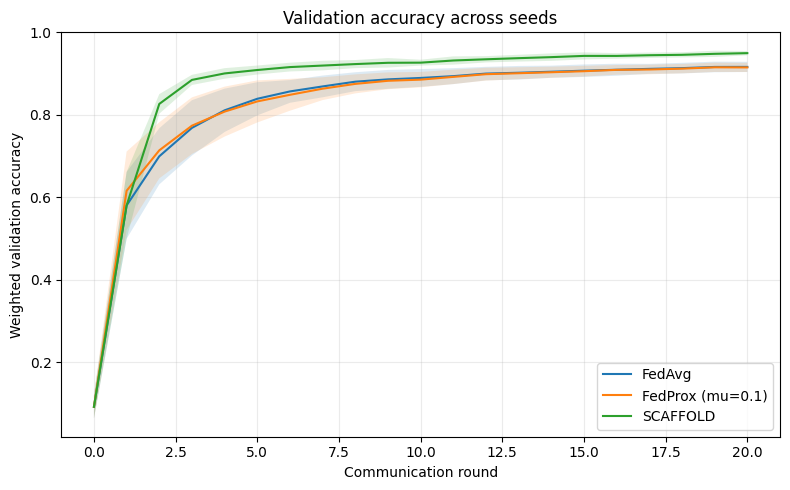

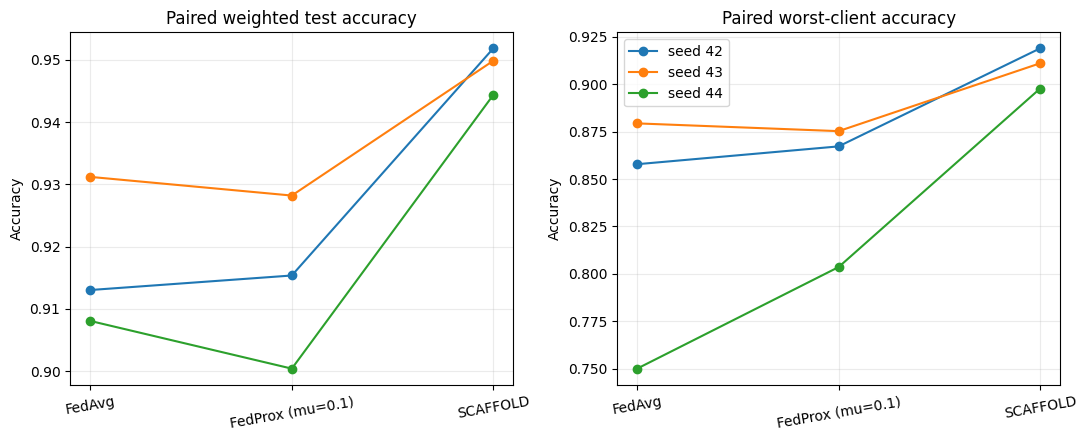

In [13]:
FIGURE_DIR = CONFIG.results_dir / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
METHOD_ORDER = ["fedavg", "fedprox", "scaffold"]
METHOD_LABELS = {"fedavg": "FedAvg", "fedprox": "FedProx (mu=0.1)", "scaffold": "SCAFFOLD"}

fig, ax = plt.subplots(figsize=(8, 5))
trajectory = (
    performance_all.groupby(["method", "round"])["weighted_validation_accuracy"]
    .agg(["mean", "std"]).reset_index()
)
for method in METHOD_ORDER:
    group = trajectory.query("method == @method")
    x = group["round"].to_numpy()
    mean = group["mean"].to_numpy()
    std = group["std"].fillna(0).to_numpy()
    ax.plot(x, mean, label=METHOD_LABELS[method])
    ax.fill_between(x, mean - std, mean + std, alpha=0.15)
ax.set(title="Validation accuracy across seeds", xlabel="Communication round", ylabel="Weighted validation accuracy")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_trajectories.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for seed, group in seed_method_summary.groupby("seed"):
    ordered = group.set_index("method").loc[METHOD_ORDER]
    axes[0].plot(METHOD_ORDER, ordered["final_weighted_test_accuracy"], marker="o", label=f"seed {seed}")
    axes[1].plot(METHOD_ORDER, ordered["final_worst_client_accuracy"], marker="o", label=f"seed {seed}")
axes[0].set_title("Paired weighted test accuracy")
axes[1].set_title("Paired worst-client accuracy")
for ax in axes:
    ax.set_xticks(range(3), [METHOD_LABELS[m] for m in METHOD_ORDER], rotation=10)
    ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "paired_final_accuracy.png", dpi=180, bbox_inches="tight")
plt.show()

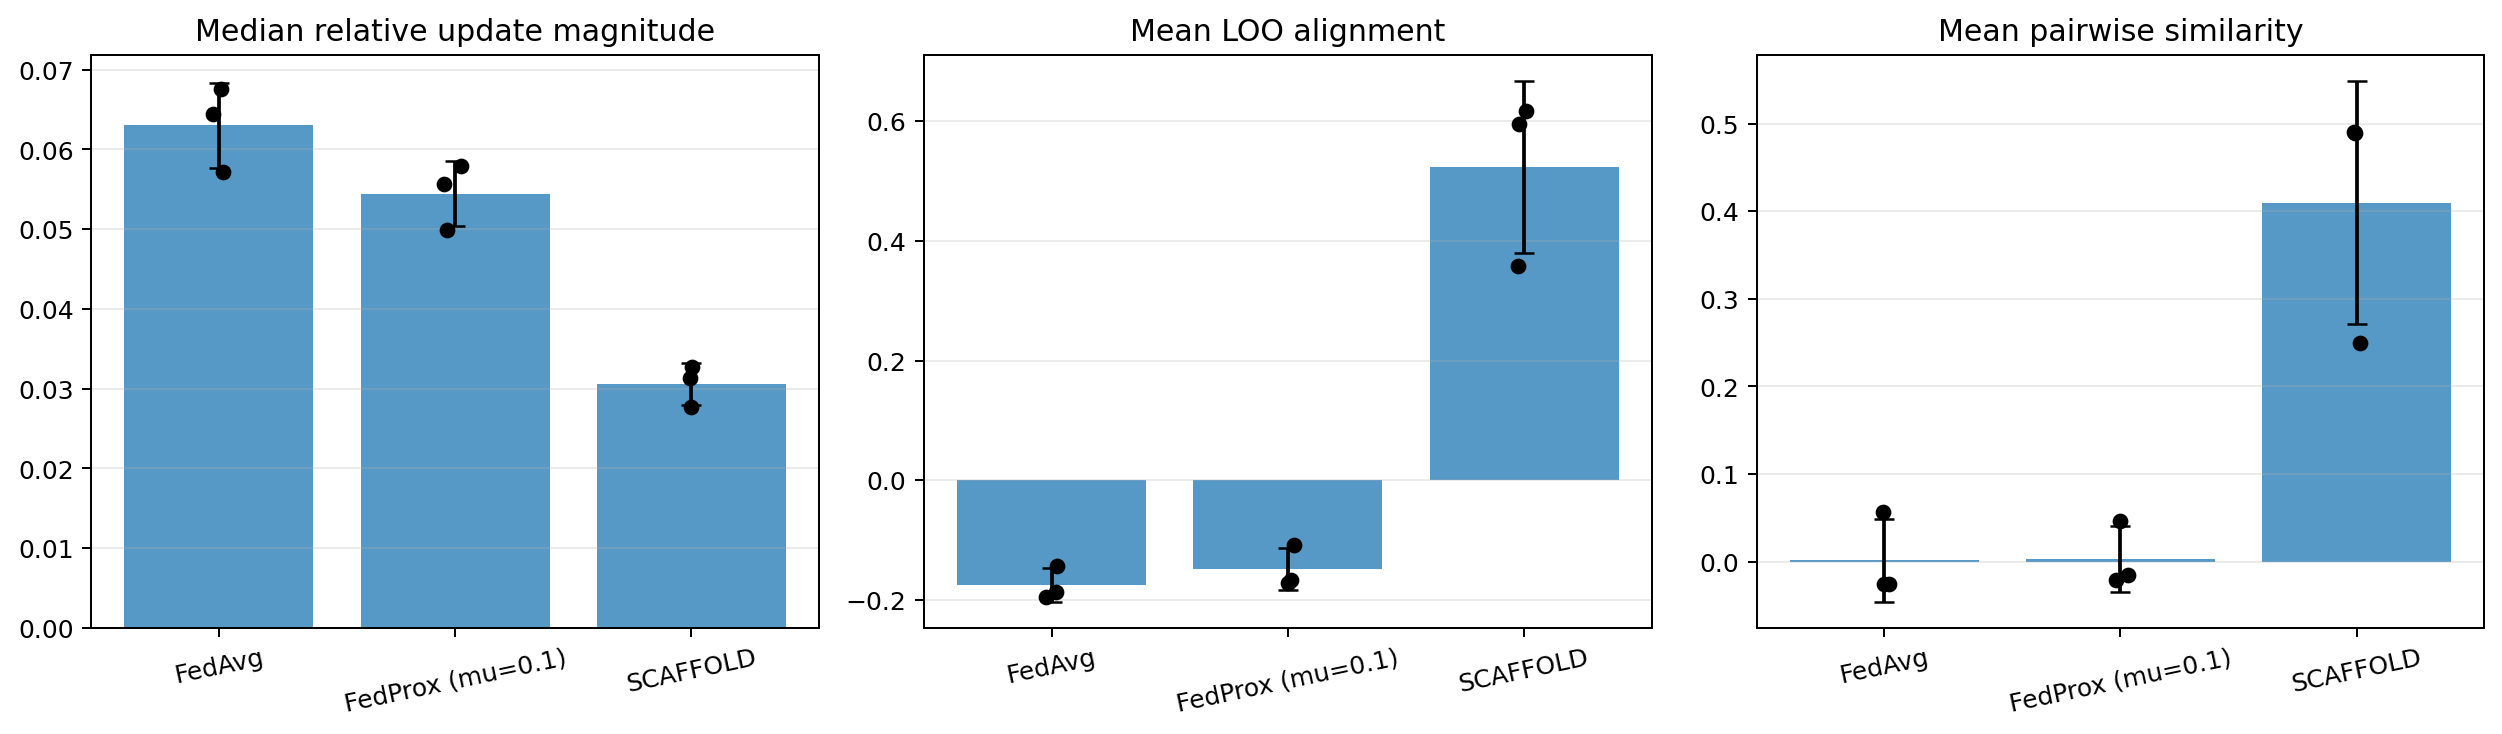

,method,seed,num_clients,model_bytes,control_bytes,extra_server_state_bytes,extra_client_state_bytes_per_client,extra_client_state_bytes_total,baseline_communication_bytes_per_round,additional_control_bytes_per_round,total_communication_bytes_per_round,additional_transmitted_values_per_round
0,scaffold,42,5,407080,407080,407080,407080,2035400,4070800,4070800,8141600,1017700
1,scaffold,43,5,407080,407080,407080,407080,2035400,4070800,4070800,8141600,1017700
2,scaffold,44,5,407080,407080,407080,407080,2035400,4070800,4070800,8141600,1017700


In [14]:
geometry_metrics = [
    ("median_relative_update_magnitude", "Median relative update magnitude"),
    ("mean_loo_alignment", "Mean LOO alignment"),
    ("mean_pairwise_similarity", "Mean pairwise similarity"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
rng = np.random.default_rng(42)

for ax, (metric, title) in zip(axes, geometry_metrics):
    values = [
        seed_method_summary.query("method == @method")[metric].to_numpy()
        for method in METHOD_ORDER
    ]
    means = [value.mean() for value in values]
    stds = [value.std(ddof=1) for value in values]
    ax.bar(range(3), means, yerr=stds, capsize=4, alpha=0.75)
    for method_index, method_values in enumerate(values):
        jitter = rng.normal(0, 0.025, size=len(method_values))
        ax.scatter(
            method_index + jitter,
            method_values,
            color="black",
            s=28,
            zorder=3,
        )
    ax.set_xticks(
        range(3),
        [METHOD_LABELS[method] for method in METHOD_ORDER],
        rotation=12,
    )
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "geometry_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

display(scaffold_tables["cost"])


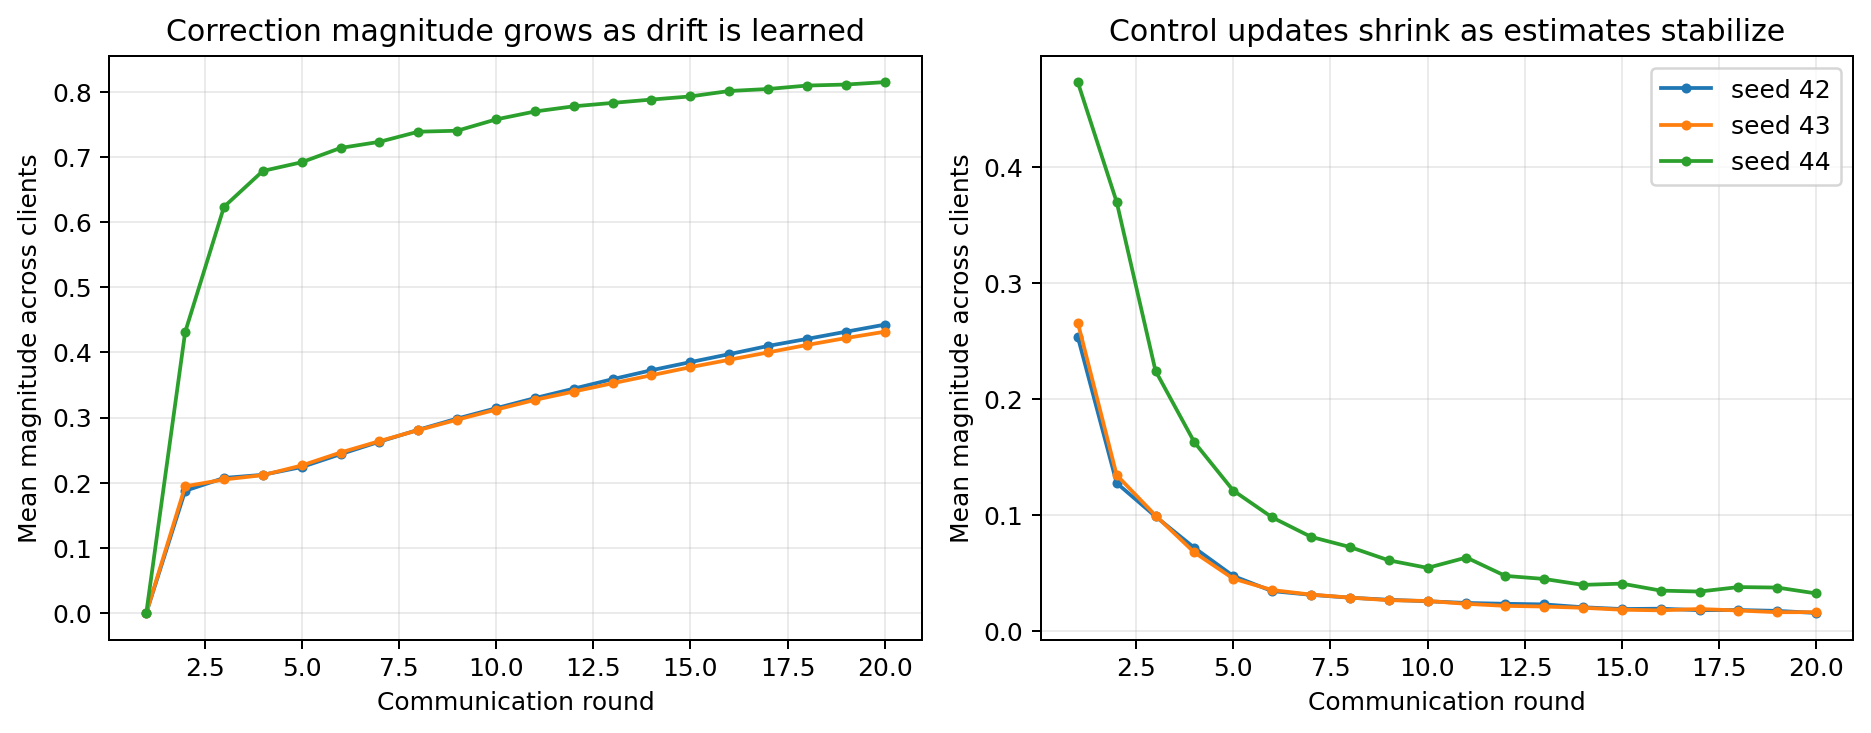

In [15]:
control_trajectory = (
    scaffold_tables["client_diagnostics"]
    .groupby(["seed", "round"], as_index=False)
    .agg(
        mean_correction_magnitude=("correction_magnitude", "mean"),
        mean_control_delta_magnitude=("control_delta_magnitude", "mean"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
for seed, group in control_trajectory.groupby("seed"):
    axes[0].plot(
        group["round"],
        group["mean_correction_magnitude"],
        marker="o",
        markersize=3,
        label=f"seed {seed}",
    )
    axes[1].plot(
        group["round"],
        group["mean_control_delta_magnitude"],
        marker="o",
        markersize=3,
        label=f"seed {seed}",
    )

axes[0].set_title("Correction magnitude grows as drift is learned")
axes[1].set_title("Control updates shrink as estimates stabilize")
for ax in axes:
    ax.set_xlabel("Communication round")
    ax.set_ylabel("Mean magnitude across clients")
    ax.grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "control_state_trajectories.png", dpi=180, bbox_inches="tight")
plt.show()


## 12. Result validation

The saved artifact set is complete: 63 performance rows, 300 client diagnostic rows,
600 pairwise rows, 60 round rows, and 15 final client-test rows. All numeric values are
finite, client weights sum to one, and weighted validation accuracy recomputes exactly
from the per-client histories.

SCAFFOLD matches FedAvg exactly at round 0 and round 1. This is expected: every control
variate starts at zero, so the first SCAFFOLD round is mathematically equivalent to
FedAvg. The methods separate only after the controls have observed one local trajectory.
Client test-set sizes also match Notebook 06 exactly. These checks substantially reduce
the likelihood that the improvement is caused by different initialization, evaluation
data, or a shifted first-round minibatch schedule.


## 13. Findings

### Performance and fairness

Across three matched seeded client populations, sample-size-weighted SCAFFOLD achieved
**94.87% ± 0.39%** final weighted test accuracy, compared with **91.74% ± 1.22%** for
FedAvg and **91.47% ± 1.39%** for moderate FedProx. Relative to FedAvg, the paired
weighted-accuracy improvement averaged **+3.13 percentage points** and was positive in
**3/3 seeds**.

Worst-client accuracy increased from **82.91%** under FedAvg to **90.92%** under
SCAFFOLD, a mean paired improvement of **+8.02 percentage points**. Mean client accuracy
improved by **+4.78 percentage points**, while the standard deviation across client
accuracies fell from **4.45%** to **2.24%**. SCAFFOLD improved 14 of 15 client-seed
comparisons relative to FedAvg and all 15 relative to FedProx. The largest fairness gain
occurred in the most imbalanced partition, seed 44, but the overall result was positive
in every seed rather than being driven solely by that partition.

### Convergence and update geometry

Normalized validation AUC increased by **+4.79 percentage points** relative to FedAvg.
SCAFFOLD reached 90% validation accuracy in 4–6 rounds across the three seeds, whereas
FedAvg required 8–17 rounds and FedProx required 9–16 rounds.

Median relative update magnitude fell from **0.0630** under FedAvg to **0.0306** under
SCAFFOLD. More importantly, mean leave-one-out alignment changed from **−0.175** to
**+0.523**, and mean pairwise similarity changed from approximately zero (**0.0016**)
to **0.410**. FedProx reduced update magnitude more modestly but left both agreement
metrics near their FedAvg values. The most defensible interpretation is therefore that
direct drift correction changes not only how far clients move, but whether their updates
reinforce or cancel one another.

The persistent-state diagnostics support the intended mechanism: correction magnitudes
grow as client-specific drift is learned, while control-delta magnitudes shrink over
rounds as the control estimates stabilize. Because improved alignment is an intended
effect of SCAFFOLD, it should be described as mechanistically consistent evidence rather
than independent causal proof.

### Storage and communication cost

The MLP contains 101,770 trainable values. SCAFFOLD adds one 407,080-byte server control
state and one control state of the same size per client, for **2.44 MB** of extra state
across the server and five clients. Under full-vector accounting, communication rises
from **4.07 MB** to **8.14 MB per round**, or approximately **162.83 MB over 20 rounds**.
This estimate excludes protocol overhead and compression. SCAFFOLD's faster convergence
suggests that communication-to-target accuracy should also be examined, not only the
fixed-round total.

Runtime values are retained only as descriptive metadata. They are not compared across
methods because the baseline timer includes the complete experiment call, while the
SCAFFOLD timer excludes validation and diagnostic construction.

### Conclusion

Within this full-participation MLP study, explicitly correcting client drift is more
effective and more consistent than merely constraining local update magnitude. SCAFFOLD
improves performance, worst-client behavior, convergence, and update agreement across
all three matched seeds. The conclusion remains limited to three seeds, five clients,
one Dirichlet concentration (`alpha = 0.1`), one architecture, and a sample-size-weighted
SCAFFOLD variant; it is descriptive rather than a claim of statistical significance.

The next experiment should test whether this advantage survives an architecture change
to the planned small custom CNN while reusing the same saved partitions.
